# FWI 3-Panel: GFDL-ESM4 vs MRI-ESM2-0 (Avg RH) vs MRI-ESM2-0 (Min RH)

Loads pre-computed annual FWI means from each model's FWI_Compute cache.

In [2]:
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd


## 1  Cache paths & scenarios

In [4]:
GFDL_CACHE    = Path("/Users/thunthita/ClimateChangeonWildfire/new/src/GFDL_ESM4/computed_means_GFDL-ESM4")
HURS_CACHE    = Path("/Users/thunthita/ClimateChangeonWildfire/new/src/MRI-ESM2/hurs/computed_means_MRI-ESM2-0")
HURSMIN_CACHE = Path("/Users/thunthita/ClimateChangeonWildfire/new/src/MRI-ESM2/hursmin/computed_means_MRI-ESM2-0_hursmin")

GFDL_SCENARIOS    = ["historical", "ssp119", "ssp126", "ssp245", "ssp370", "ssp585"]
HURS_SCENARIOS    = ["historical", "ssp119", "ssp126", "ssp245", "ssp370", "ssp434", "ssp460", "ssp534", "ssp585"]
HURSMIN_SCENARIOS = ["historical", "ssp119", "ssp126", "ssp245", "ssp370", "ssp460", "ssp534", "ssp585"]


## 2  Load from cache

In [6]:
def load_fwi_cache(cache_dir: Path, scenarios: list) -> dict:
    """Return {scenario_key: DataArray(year)} from pre-computed NetCDF files."""
    out = {}
    for s in scenarios:
        f = cache_dir / f"fwi_{s}.nc"
        if f.exists():
            out[s] = xr.open_dataarray(f).load()
        else:
            print(f"  [warn] missing: {f}")
    return out

gfdl_fwi    = load_fwi_cache(GFDL_CACHE,    GFDL_SCENARIOS)
hurs_fwi    = load_fwi_cache(HURS_CACHE,    HURS_SCENARIOS)
hursmin_fwi = load_fwi_cache(HURSMIN_CACHE, HURSMIN_SCENARIOS)

print("GFDL    :", list(gfdl_fwi.keys()))
print("hurs    :", list(hurs_fwi.keys()))
print("hursmin :", list(hursmin_fwi.keys()))


GFDL    : ['historical', 'ssp119', 'ssp126', 'ssp245', 'ssp370', 'ssp585']
hurs    : ['historical', 'ssp119', 'ssp126', 'ssp245', 'ssp370', 'ssp434', 'ssp460', 'ssp534', 'ssp585']
hursmin : ['historical', 'ssp119', 'ssp126', 'ssp245', 'ssp370', 'ssp460', 'ssp534', 'ssp585']


## 3  Palette, labels & helpers

In [8]:
# ── Palette ───────────────────────────────────────────────────────────────────
color_blind_palette = {
    "historical": "#000000",
    "ssp119":     "#E69F00",
    "ssp126":     "#56B4E9",
    "ssp245":     "#009E73",
    "ssp370":     "#882255",
    "ssp434":     "#E6D600",
    "ssp460":     "#D55E00",
    "ssp534":     "#0072B2",
    "ssp585":     "#CC79A7",
}

SHORT_LABELS = {
    "historical": "Historical",
    "ssp119": "SSP1-1.9",  "ssp126": "SSP1-2.6",
    "ssp245": "SSP2-4.5",  "ssp370": "SSP3-7.0",
    "ssp434": "SSP4-3.4",  "ssp460": "SSP4-6.0",
    "ssp534": "SSP5-3.4OS","ssp585": "SSP5-8.5",
}

LONG_LABELS = {
    "historical": "Historical to Present (1850–2015)",
    "ssp119": "SSP1-1.9 (“Sustainability — Very Low Emissions”)",
    "ssp126": "SSP1-2.6 (“Sustainability — Low Emissions”)",
    "ssp245": "SSP2-4.5 (“Middle of the Road — Moderate Emissions”)",
    "ssp370": "SSP3-7.0 (“Regional Rivalry — High Emissions”)",
    "ssp434": "SSP4-3.4 (“Inequality”)",
    "ssp460": "SSP4-6.0 (“Inequality — Medium Emissions”)",
    "ssp534": "SSP5-3.4OS (“Fossil-Fueled Dev. + Overshoot”)",
    "ssp585": "SSP5-8.5 (“Fossil-Fueled Development”)",
}

# Canonical scenario order for sorting
_SCENARIO_RANK = {s: i for i, s in enumerate(
    ["historical","ssp119","ssp126","ssp245","ssp370","ssp434","ssp460","ssp534","ssp585"]
)}

def _scenario_rank(key):    return _SCENARIO_RANK.get(key, 99)
def _long_label_for(key):   return LONG_LABELS.get(key, key)
def _color_for_label(key):  return color_blind_palette.get(key, "#000000")

def _apply_rolling(arr, window):
    if window and window > 1:
        return pd.Series(arr).rolling(window, center=True, min_periods=1).mean().values
    return arr

def _present_keys_in_order(*fwi_dicts):
    """Unique scenario keys present in any of the dicts, in canonical order."""
    seen = set()
    out  = []
    for d in fwi_dicts:
        for k in d:
            if k not in seen:
                seen.add(k)
                out.append(k)
    return sorted(out, key=_scenario_rank)


## 4  Plot functions

In [10]:
def _plot_panel(ax, fwi_dict: dict, smooth_window=None):
    """Plot time-series from cache dict {scenario: DataArray(year)}, sorted in canonical order."""
    for scen in sorted(fwi_dict, key=_scenario_rank):
        da    = fwi_dict[scen]
        years = da["year"].values
        vals  = _apply_rolling(da.values, smooth_window)
        ax.plot(years, vals, label=_long_label_for(scen), linewidth=1.2,
                alpha=0.95, color=_color_for_label(scen))
    ax.grid(True, alpha=0.5)
    ax.tick_params(labelsize=16)

def set_split_title(ax, left, right="", fontsize=19):
    ax.set_title(left, loc="left", fontsize=fontsize)
    if right:
        ax.text(1.0, 1.02, right, transform=ax.transAxes,
                ha="right", va="bottom", fontsize=fontsize)


def plot_fwi_3panel(
    gfdl_fwi:    dict,
    hurs_fwi:    dict,
    hursmin_fwi: dict,
    smooth_window: int = 10,
    output_path:   str = "Pict/FWI_3panel_all_models.png",
):
    """
    Layout (Elsevier double-column 190 mm = 7.48 in, min font 8 pt):
      [0,0] GFDL-ESM4              [0,1] SSP legend
      [1,0] MRI-ESM2-0 Avg RH      [1,1] MRI-ESM2-0 Min RH
    sharey=True across all panels.
    """
    Path(output_path).parent.mkdir(parents=True, exist_ok=True)

    fig, axes = plt.subplots(2, 2, figsize=(7.48, 3.3), sharey=True)
    axG   = axes[0, 0]
    axSSP = axes[0, 1]
    axH   = axes[1, 0]
    axMIN = axes[1, 1]

    # ── [0,0] GFDL-ESM4 ───────────────────────────────────────────────────────
    _plot_panel(axG, gfdl_fwi, smooth_window)
    set_split_title(axG, "a) GFDL-ESM4 Avg RH", "")
    axG.set_ylabel("FWI", fontsize=19)

    # ── [0,1] SSP Legend ──────────────────────────────────────────────────────
    axSSP.set_title("SSP", fontsize=19, loc="left")
    axSSP.axis("off")
    present = _present_keys_in_order(gfdl_fwi, hurs_fwi, hursmin_fwi)
    handles = []
    legend_texts = []
    for k in present:
        line, = axSSP.plot([], [], color=_color_for_label(k), linewidth=2.0)
        handles.append(line)
        legend_texts.append(SHORT_LABELS.get(k, k))
    axSSP.legend(handles, legend_texts, loc="upper left", frameon=False, fontsize=13, ncol=1)

    # ── [1,0] MRI-ESM2-0 Avg RH (hurs) ───────────────────────────────────────
    _plot_panel(axH, hurs_fwi, smooth_window)
    set_split_title(axH, "b) MRI-ESM2-0 Avg RH", "")
    axH.set_ylabel("FWI", fontsize=19)

    # ── [1,1] MRI-ESM2-0 Min RH (hursmin) ────────────────────────────────────
    _plot_panel(axMIN, hursmin_fwi, smooth_window)
    set_split_title(axMIN, "c) MRI-ESM2-0 Min RH", "")

    # ── Shared x-axis formatting ───────────────────────────────────────────────
    years = [1850, 1900, 1950, 2000, 2050, 2100]
    for ax in [axG, axH, axMIN]:
        ax.set_xlim(1850, 2100)
        ax.set_ylim(bottom=15)
        ax.set_xticks(years)
        ax.set_xticklabels([str(y) for y in years])

    plt.subplots_adjust(left=0.08, right=1.5, bottom=0.1, top=1.7,
                        wspace=0.15, hspace=0.35)
    plt.savefig(output_path, dpi=300, bbox_inches="tight", transparent=False)
    print(f"Saved → {output_path}")
    plt.show()


## 5  Run

Saved → Pict/FWI_3panel_all_models.png


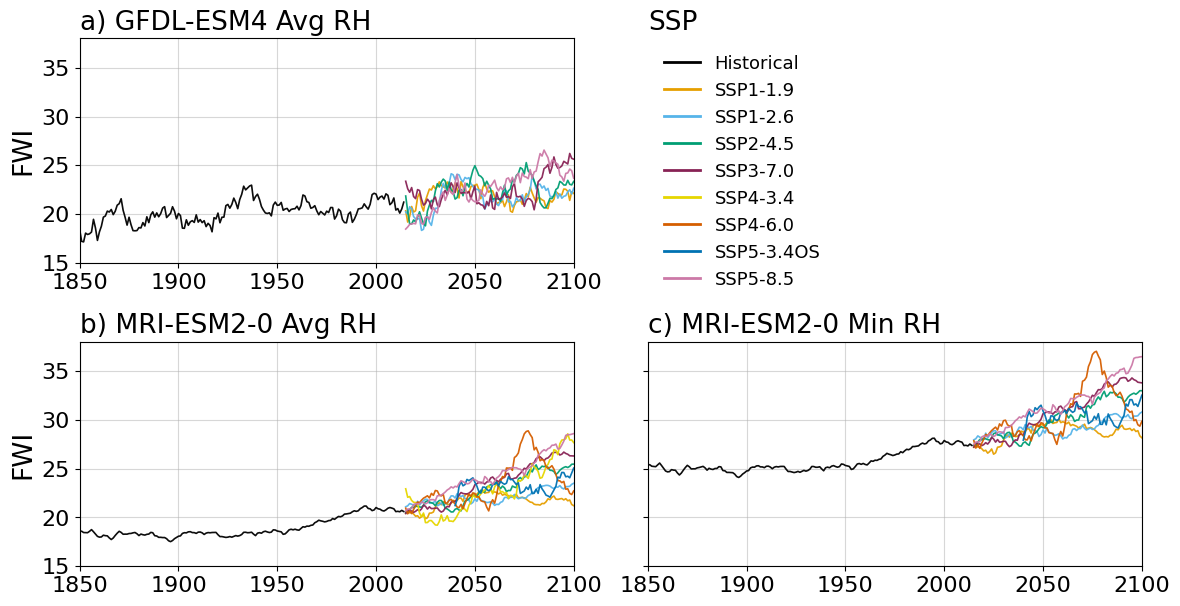

In [12]:
plot_fwi_3panel(
    gfdl_fwi      = gfdl_fwi,
    hurs_fwi      = hurs_fwi,
    hursmin_fwi   = hursmin_fwi,
    smooth_window = 10,
    output_path   = "Pict/FWI_3panel_all_models.png",
)


Years compared: 1850–2014  (n=165)
Raw   mean ± std: 20.1880 ± 4.3930
Cache mean ± std: 20.1880 ± 4.3930
Max abs diff    : 0.000000
Mean abs diff   : 0.000000
Correlation     : 1.00000000


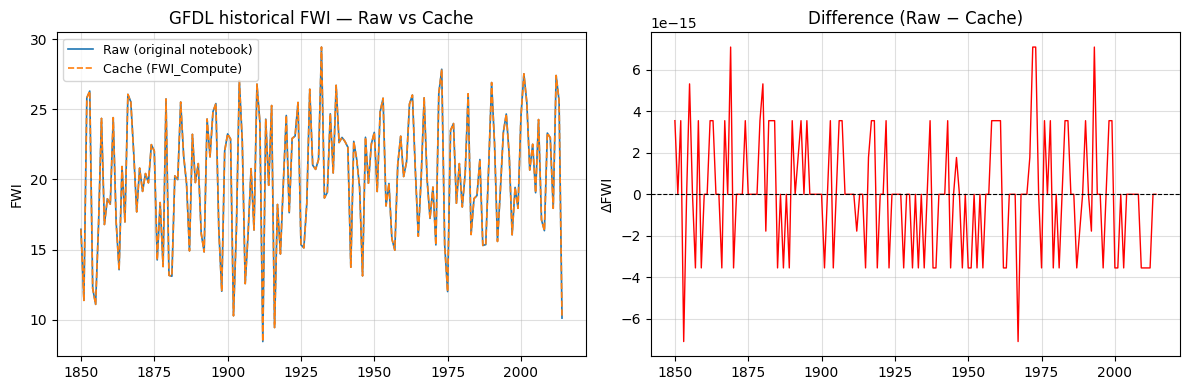

In [13]:
# ── Diagnostic: compare cache vs raw for GFDL historical ──────────────────────
import xarray as xr
import numpy as np

BASE_CMIP6 = "/Volumes/jubjang/Jubjang/FWICMIP6"

# --- Method A: raw file (same as original notebook) ---
ds_raw = xr.open_dataset(f"{BASE_CMIP6}/fwisa_ann_GFDL-ESM4_historical_r1i1p1f1_g025.nc")
da_raw = ds_raw["fwisa"].sel(lat=slice(5.5, 20.5), lon=slice(97.5, 105.5))

# Spherical area weights (same formula as original notebook)
R = 6_378_137
lat_r = np.radians(da_raw.lat.values)
lon_r = np.radians(da_raw.lon.values)
dlon  = np.diff(lon_r)[0]
dlat  = np.diff(lat_r).mean()
area  = np.zeros((len(lat_r), len(lon_r)))
for i, phi in enumerate(lat_r):
    area[i, :] = R**2 * dlon * (np.sin(phi + dlat/2) - np.sin(phi - dlat/2))
area_da = xr.DataArray(area, dims=["lat","lon"],
                        coords={"lat": da_raw.lat, "lon": da_raw.lon})
mean_raw = da_raw.weighted(area_da).mean(dim=["lat","lon"])
# annual mean (raw file is already annual → just groupby year)
mean_raw_annual = mean_raw.groupby("time.year").mean()

# --- Method B: cache ---
mean_cache = gfdl_fwi["historical"]   # DataArray(year)

# --- Compare ---
# Align on common years
common_years = np.intersect1d(mean_raw_annual["year"].values, mean_cache["year"].values)
a = mean_raw_annual.sel(year=common_years).values
b = mean_cache.sel(year=common_years).values

print(f"Years compared: {common_years[0]}–{common_years[-1]}  (n={len(common_years)})")
print(f"Raw   mean ± std: {a.mean():.4f} ± {a.std():.4f}")
print(f"Cache mean ± std: {b.mean():.4f} ± {b.std():.4f}")
print(f"Max abs diff    : {np.abs(a - b).max():.6f}")
print(f"Mean abs diff   : {np.abs(a - b).mean():.6f}")
print(f"Correlation     : {np.corrcoef(a, b)[0,1]:.8f}")

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(common_years, a, label="Raw (original notebook)", linewidth=1.2)
axes[0].plot(common_years, b, label="Cache (FWI_Compute)", linewidth=1.2, linestyle="--")
axes[0].set_title("GFDL historical FWI — Raw vs Cache")
axes[0].legend(fontsize=9)
axes[0].set_ylabel("FWI")
axes[0].grid(True, alpha=0.4)

axes[1].plot(common_years, a - b, color="red", linewidth=1.0)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Difference (Raw − Cache)")
axes[1].set_ylabel("ΔFWI")
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()
